<a href="https://colab.research.google.com/github/SAR-DINE-procom/traitement/blob/master/sar_simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup du notebook

### Très important : l'exécution de matlab ne fonctionne que sur Google Chrome.
Les prochaines cellules permettent de mettre en place le notebook pour réaliser la simulation de données SAR.

Veuillez lancer la première cellule, cela permettra de récupérer le script d'installation de matlab.


In [1]:
# from google.colab import userdata
# token_github = userdata.get('github')
# !git clone "https://{token_github}@github.com/SAR-DINE-procom/traitement.git"
# # test 2
# !wget --header 'Authorization: token {token_github}' -O install-matlab.sh https://github.com/SAR-DINE-procom/traitement/raw/master/install_matlab.sh
!wget https://gist.githubusercontent.com/WW9kYQ/c3943f343ba77dd1d1fa468b71ef68ef/raw/2ae6cedf691b594b496b2b2b7cb6d01154979d13/install-matlab.sh
!chmod +x install-matlab.sh

--2025-11-13 13:47:16--  https://gist.githubusercontent.com/WW9kYQ/c3943f343ba77dd1d1fa468b71ef68ef/raw/2ae6cedf691b594b496b2b2b7cb6d01154979d13/install-matlab.sh
Resolving gist.githubusercontent.com (gist.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to gist.githubusercontent.com (gist.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 852 [text/plain]
Saving to: ‘install-matlab.sh’

install-matlab.sh   100%[===================>]     852  --.-KB/s    in 0.002s  

2025-11-13 13:47:16 (397 KB/s) - ‘install-matlab.sh’ saved [852/852]



Dirigez-vous maintenant dans l'onglet terminal (en bas à droite), et exécutez la commande suivante :
`./install-matlab.sh`

Une fois que vous avez le message vous indiquant que le service de matlab est bien démarré, copiez le token du lien et conserver le pour la session.

Lancez ensuite la cellule suivante et cliquez sur le lien `https://localhost:3000/` qui apparait. Renseignez le token et authentifiez vous.

Patientez le temps que matlab démarre.

In [2]:
from google.colab import output
output.serve_kernel_port_as_window(3000, path='/')

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

Une fois matlab démarré, exécutez la cellule ci-dessous.

In [3]:
import matlab.engine

e = matlab.engine.start_matlab("-licmode onlinelicensing")

Votre environnement de développement Python est maintenant relié à matlab via son kernel, pour y faire appel, utilisez `e.[fonction_matlab]`.

In [4]:
# IMPORT DES LIBRAIRIES
import math
import numpy as np
import matplotlib.pyplot as plt

Simulation terminée.


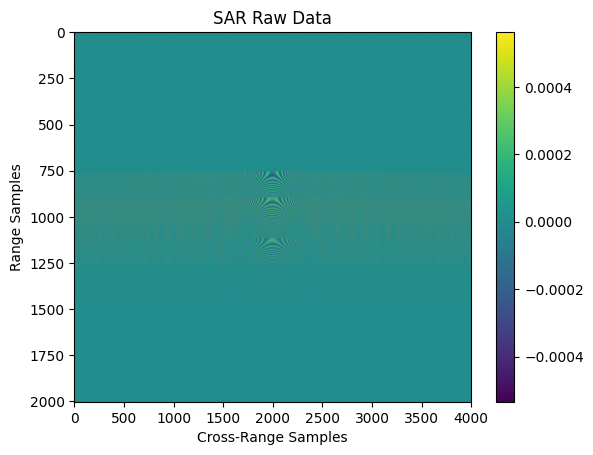

In [8]:

# Cette cellule comprend la simulation d'un SAR FMCW, or dans notre cas, il n'est pas possible de sauvegarder les données expérimentales. Il reste la pour le moment mais le vrai simu est implanté plus bas


# config radar et paramètres de base
c = e.physconst('LightSpeed')
fc = 4.0e9
rangeResolution = 3.0
crossRangeResolution = 3.
bw = c/(2*rangeResolution)
prf = 1000.0
aperture = 4.0
tpd = 3.0*math.pow(10,-6)
fs = 120.0*math.pow(10,6)

waveform = e.phased.LinearFMWaveform('SampleRate',fs, 'PulseWidth', tpd, 'PRF', prf, 'SweepBandwidth', bw);

speed = 100.0
flightDuration = 4
pos = np.array([[0], [-200], [500]], dtype=float)
vel = np.array([[0], [speed], [0]], dtype=float)

radarPlatform = e.phased.Platform('InitialPosition', pos,'Velocity', vel,nargout=1)

slowTime = 1/prf
numpulses = flightDuration/slowTime +1
maxRange = 2500
truncrangesamples = e.ceil((2*maxRange/c)*fs)
fastTime = np.arange(truncrangesamples) / fs
RC = 1000

freq_range = matlab.double([1e9, 6e9])
antenna = e.phased.CosineAntennaElement('FrequencyRange', freq_range, nargout=1)

antennaGain = e.aperture2gain(aperture, c / fc, nargout=1)

transmitter = e.phased.Transmitter('PeakPower', 50e3, 'Gain', antennaGain, nargout=1)

radiator = e.phased.Radiator('Sensor', antenna, 'OperatingFrequency', fc, 'PropagationSpeed', c, nargout=1)

collector = e.phased.Collector('Sensor', antenna, 'PropagationSpeed', c, 'OperatingFrequency', fc, nargout=1)

receiver = e.phased.ReceiverPreamp('SampleRate', fs, 'NoiseFigure', 30.0, nargout=1)

channel = e.phased.FreeSpace('PropagationSpeed', c, 'OperatingFrequency', fc, 'SampleRate', fs, 'TwoWayPropagation', True, nargout=1)

# Config scene
targetpos_np = np.array([[800, 0, 0],
                         [1000, 0, 0],
                         [1300, 0, 0]], dtype=float).T
# targetpos_np est maintenant :
# [[ 800. 1000. 1300.]
#  [   0.    0.    0.]
#  [   0.    0.    0.]]

targetvel_np = np.zeros((3, 3), dtype=float)

mean_rcs = matlab.double([1.0, 1.0, 1.0])
target = e.phased.RadarTarget('OperatingFrequency', fc, 'MeanRCS', mean_rcs, nargout=1)

pointTargets = e.phased.Platform('InitialPosition', targetpos_np, 'Velocity', targetvel_np, nargout=1)

num_targets = targetpos_np.shape[1]
refangle = np.zeros(num_targets)

rxsig = np.zeros((int(truncrangesamples), int(numpulses)), dtype=np.complex128)

for ii in range(int(numpulses)):
    radarpos, radarvel = e.step(radarPlatform, slowTime, nargout=2)
    targetpos, targetvel = e.step(pointTargets, slowTime, nargout=2)

    targetRange, targetAngle = e.rangeangle(targetpos, radarpos, nargout=2)

    sig = e.step(waveform, nargout=1)

    sig = sig[0:int(truncrangesamples)]

    sig = e.step(transmitter, sig, nargout=1)

    targetAngle_np = np.array(targetAngle)
    targetAngle_np[0, :] = refangle
    targetAngle_mod = matlab.double(targetAngle_np.tolist())

    sig = e.step(radiator, sig, targetAngle_mod, nargout=1)

    sig = e.step(channel, sig, radarpos, targetpos, radarvel, targetvel, nargout=1)

    sig = e.step(target, sig, nargout=1)

    sig = e.step(collector, sig, targetAngle_mod, nargout=1)

    sig_received = e.step(receiver, sig, nargout=1)

    rxsig[:, ii] = np.array(sig_received).squeeze()

print("Simulation terminée.")

# Sauvegarde données :
np.save('raw_data.npy', rxsig)

# --- Affichage (avec Matplotlib) ---

# figure(1);
plt.figure(1)
plt.imshow(np.real(rxsig), aspect='auto', origin='upper')
plt.colorbar()
plt.title('SAR Raw Data')
plt.xlabel('Cross-Range Samples')
plt.ylabel('Range Samples')
plt.show()

In [ ]:

# Load the .npy file
rxsig = np.load('raw_data.npy')

# Save the numpy array to a CSV file
# Using fmt='%s' to handle complex numbers by saving them as strings.
# For purely real or imaginary data, a numeric format could be used.
np.savetxt('raw_data.csv', rxsig, delimiter=',', fmt='%s')

print("raw_data.npy successfully converted to raw_data.csv")

# Début du simulateur
La cellule suivante regroupe les paramètres généraux du radar.

In [22]:
# Vitesse de la lumière :
c = e.physconst('LightSpeed')
# Fréquence porteuse : 24.15 GHz
fc = 24.15e9
# Bande passante : 180 MHz
bw = 180.0e6
# Résolution en distance
rangeResolution = c / (2 * bw)
# Vitesse du capteur, dans le cas d'une mesure sur le bras UR10e, le robot peut aller à 4m/s max, on peut penser à une durée d'intégration de 20s sur 1m => 0.05 m/s
speed = 0.05
# Durée de vol du SAR
flightDuration = 1.0/speed

# Définition de la position initiale, vérifier pour Z, voir les implications pour X et Y
#                 X     Y     Z
pos = np.array([[0.0],[0.0],[1.0]], dtype=float)
# Vecteur de déplacement, déplacement selon une direction unique
vel = np.array([[0.0],[speed],[0.0]], dtype=float)

# Portée maximale
maxRange = 20.0

# Paramètres des antennes
# Gain de l'antenne MC4 (la grosse) = 13dBi
gain = 13.0

# Puissance d'émission de la carte : 5dBm
txPowerdBm = 5.0
txPowerLin = math.pow(10.0, txPowerdBm/10.0) * math.pow(10.0,-3.0)

# Figure de bruit : NF = sensibilité_recepteur - puissance de bruit - SNR, avec l'antenne MC4 : NF = -116dBm - (-174+30) - 6 = 22dB, Puissance de bruit + dB pour la passer en dBm
noiseFigure = 22.0

# Calcul gain recepteur (gain LNA - perte conversion mixer + gain IF):
receiverGaindB = 16 - 12.5 + 20

# largeur 3dB du diagramme d'antenne en azimut et élévation
beamwidth_az = 30.0
beamwidth_el = 12.0

Simulateur FSK

In [33]:
# Fréquence d'échantillonnage de l'ADC de la carte
fs = 250.0e3

# Définition de la PRF, elle doit être supérieur à la f_doppler_max, dans notre cas, déplacement de 0.05 m/s => 8.06 Hz, on prend 20 pour être large
prf = 20.0

# Nombres de sautes de fréquences, choix arbitraire ici. La carte gère du FMCW donc le VCO doit être assez performant pour faire au moins 100 sauts de fréquences :
numSteps = 100.0
frequencyStep = bw / (numSteps - 1)

# Durée d'un saut de fréquence (dwell time). avec prf = 20 et 100 sauts on a 20*100 = 2000 sauts par seconde. la durée total d'un cycle est de 1/prf = 50ms, chaque saut dure donc 500µs. Avec une f_ech = 250kHz, on a un ech toutes les 4µs soit 125ech par sauts
step_duration = 500.0e-6 # 500µs

# Définition de la forme d'onde avec le paramètres qu'on a défini.
waveform = e.phased.SteppedFMWaveform('SampleRate', fs, 'NumSteps', numSteps, 'FrequencyStep', frequencyStep, 'PulseWidth', step_duration, 'PRF', prf, nargout=1)

# Création plateforme radar
radarPlatform = e.phased.Platform('InitialPosition', pos,'Velocity', vel,nargout=1)

# calcul du temps lent
slowTime = 1/prf
numpulses = flightDuration/slowTime +1

# Création de l'antenne custom avec nos paramètres :
# antenna = e.phased.GaussianAntennaElement('AzimuthBeamwidth', beamwidth_az, 'ElevationBeamwidth', beamwidth_el, 'FrequencyRange', matlab.double([fc-bw,fc+bw]), nargout=1)

antenna = e.phased.GaussianAntennaElement('Beamwidth', matlab.double([beamwidth_az,beamwidth_el]), 'FrequencyRange', matlab.double([fc-bw,fc+bw]), nargout=1)

# Définition du transmetteur :
transmitter = e.phased.Transmitter('PeakPower', txPowerLin, 'Gain', gain, nargout=1)
radiator = e.phased.Radiator('Sensor', antenna, 'OperatingFrequency', fc, 'PropagationSpeed', c, nargout=1)

# Définition du recepteur :
collector = e.phased.Collector('Sensor', antenna, 'PropagationSpeed', c, 'OperatingFrequency', fc, nargout=1)
receiver = e.phased.ReceiverPreamp('SampleRate', fs, 'NoiseFigure', noiseFigure, 'Gain', receiverGaindB, nargout=1)

# Définition du canal
channel = e.phased.WidebandFreeSpace('PropagationSpeed', c, 'OperatingFrequency', fc, 'SampleRate', fs, 'TwoWayPropagation', True, nargout=1)



# Définition des cibles :
# Positions : [X; Y; Z]
# Cible 1: 10m de distance (X), 0.3m sur la trajectoire (Y)
# Cible 2: 15m de distance (X), 0.6m sur la trajectoire (Y)
tgt_pos = matlab.double([[10.0, 15.0], [0.3, 0.6], [1.0, 1.0]])
tgt_vel = matlab.double([[0.0, 0.0], [0.0, 0.0], [0.0, 0.0]])
# Définition de la SER des cibles :
tgt_rcs_db = matlab.double([10.0, 10.0])  # 10 m^2 chacun
tgt_rcs_lin = e.db2pow(tgt_rcs_db)

# Plateforme pour les cibles :
targetPlatforms = e.phased.Platform('InitialPosition', tgt_pos, 'Velocity', tgt_vel, nargout=1)
numTargets = float(tgt_pos.size[1])

target = e.phased.RadarTarget('Model', 'Nonfluctuating', 'MeanRCS', tgt_rcs_lin, 'OperatingFrequency', fc, nargout=1)

# Assurer que numpulses est un entier pour la boucle
numpulses = int(e.floor(numpulses))
numSteps = int(numSteps)

# Calcul du nombre d'échantillons temporels
samples_per_step = int(step_duration * fs)
samples_per_pulse = samples_per_step * numSteps



# Calcul du nombre d'échantillons temporels par "burst"
samples_per_step = int(step_duration * fs) # 500e-6 * 250e3 = 125 échantillons
samples_per_pulse = samples_per_step * numSteps # 125 * 100 = 12500 échantillons

# --- INITIALISATION DU CUBE DE DONNÉES BRUTES (TEMPS x AZIMUT) ---
received_data_time = np.zeros((samples_per_pulse, numpulses), dtype=complex)
print(f"Simulation de {numpulses} impulsions (bursts) FSK...")
# Boucle principale (azimut/temps lent)
for ii in range(numpulses):

    # 1. Avancer les plateformes
    radarpos, radarvel = e.step(radarPlatform, slowTime, nargout=2)
    targetpos, targetvel = e.step(targetPlatforms, slowTime, nargout=2)

    # 2. Calculer la géométrie
    targetRange, targetAngle = e.rangeangle(targetpos, radarpos, nargout=2)

    # 3. Générer le signal FSK (un burst complet)
    sig = e.step(waveform, nargout=1)

    tiny_imaginary_part = 1e-30 # Une valeur négligeable mais non nulle
    sig_complex = e.plus(e.complex(sig), 1j * tiny_imaginary_part)

    # 4. Émettre (applique puissance et gain)
    # Utiliser la version complexe
    tx_sig = e.step(transmitter, sig_complex, nargout=1)

    # 5. Irradier (applique le diagramme d'antenne)
    # tx_sig est maintenant complexe, donc rad_sig le sera aussi
    rad_sig = e.step(radiator, tx_sig, targetAngle, nargout=1)

    # 6. Propager (via le canal large bande)
    # CETTE LIGNE NE DEVRAIT PLUS ÉCHOUER
    prop_sig = e.step(channel, rad_sig, radarpos, targetpos, radarvel, targetvel, nargout=1)

    # 7. Réflechir sur la cible (applique le RCS)
    refl_sig = e.step(target, prop_sig, nargout=1)

    # 8. Collecter (applique le diagramme d'antenne à la réception)
    coll_sig = e.step(collector, refl_sig, targetAngle, nargout=1)

    # 9. Réceptionner (Amplifier + Bruiter)
    sig_received = e.step(receiver, coll_sig, nargout=1)

    # 10. Stocker le signal temporel
    received_data_time[:, ii] = np.array(sig_received).squeeze()

print("Simulation temporelle terminée. Données brutes (temps) collectées.")



Simulation de 401 impulsions (bursts) FSK...
Simulation temporelle terminée. Données brutes (temps) collectées.


In [35]:
print("Extraction des pas de fréquence (dé-multiplexage)...")

# --- INITIALISATION DU CUBE DE DONNÉES (FRÉQUENCE x AZIMUT) ---
received_data_freq = np.zeros((numSteps, numpulses), dtype=complex)

for i in range(numpulses):
    s_pulse_time = received_data_time[:,i]
    for j in range(numSteps):
        idx = int((j + 1) * samples_per_step - 1)
        received_data_freq[j, i] = s_pulse_time[idx]

print("Cube de données [Fréquence, Azimut] assemblé.")

# ... (Votre code de 2D-FFT pour la formation d'image) ...

Extraction des pas de fréquence (dé-multiplexage)...
Cube de données [Fréquence, Azimut] assemblé.


Début de la formation d'image (2D-FFT)...
Image SAR formée.
Création des axes...
Affichage de l'image...


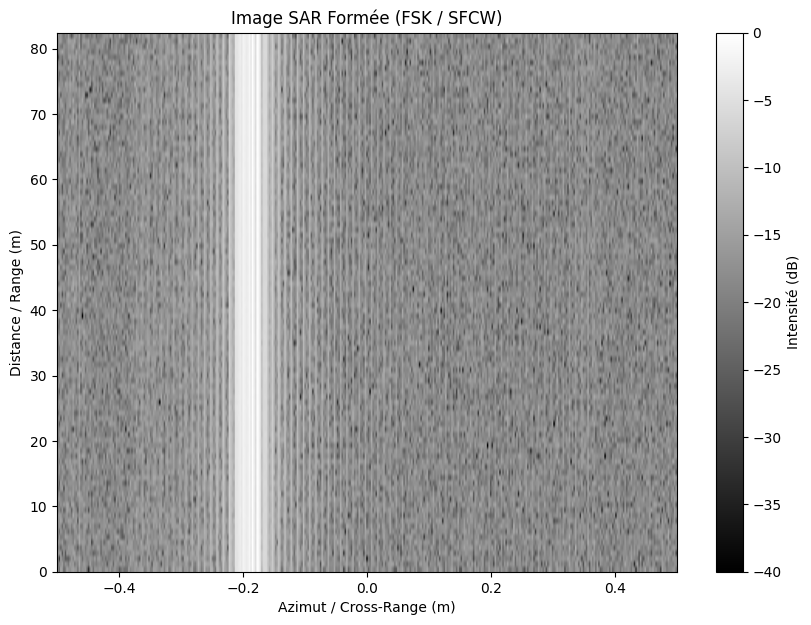

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# --- 4. FORMATION D'IMAGE (2D-FFT) ---
# Ce bloc reprend le traitement que vous aviez déjà

print("Début de la formation d'image (2D-FFT)...")

# 4.1. Compression en distance (Range Compression)
# IFFT sur l'axe des fréquences (dimension 1)
# Assurez-vous que received_data_freq est un tableau Numpy
range_data = np.fft.ifft(received_data_freq, n=numSteps, axis=0)

# 4.2. Compression en Azimut (Azimuth Compression)
# FFT sur l'axe du temps (dimension 2)
# np.fft.fftshift() centre l'image sur le Doppler 0.
azimuth_data = np.fft.fftshift(np.fft.fft(range_data, n=numpulses, axis=1), axes=1)

# L'image finale est la magnitude de ce résultat
sar_image = np.abs(azimuth_data)

# 4.3. Conversion en dB
sar_image_db = 10 * np.log10(sar_image / np.max(sar_image)) # Normalisé et en dB

print("Image SAR formée.")

# --- 5. CRÉATION DES AXES POUR L'AFFICHAGE ---

print("Création des axes...")

# 5.1. Axe des distances (Range)
# L'espacement temporel (résolution) de l'IFFT est 1/bw.
# range = c * (t / 2)
range_t = np.linspace(0.0, numSteps - 1.0, numSteps) / bw
range_axis = (c * range_t) / 2.0

# 5.2. Axe d'azimut (Cross-Range)
# (Approximation basée sur la distance totale parcourue)
total_distance = speed * flightDuration
azimuth_axis = np.linspace(-total_distance / 2.0, total_distance / 2.0, numpulses)

# --- 6. AFFICHAGE DE L'IMAGE AVEC MATPLOTLIB ---

print("Affichage de l'image...")

# 6.1. Configuration de l'affichage
# Définir les limites (extent) pour imshow
# format: [xmin, xmax, ymin, ymax]
plot_extent = [azimuth_axis.min(), azimuth_axis.max(),
               range_axis.min(), range_axis.max()]

# 6.2. Définir une plage dynamique pour l'affichage (ex: 40 dB)
min_db = -40  # Afficher tout ce qui est à -40dB du pic
max_db = 0    # Le pic est à 0dB car nous avons normalisé

# 6.3. Création du graphique
plt.figure(figsize=(10, 7))

# Utilisation de 'imshow' pour afficher l'image 2D
plt.imshow(sar_image_db,
           cmap='gray',  # 'gray' ou 'jet'
           extent=plot_extent,
           aspect='auto',
           origin='lower',
           vmin=min_db,  # Appliquer la plage dynamique min
           vmax=max_db) # Appliquer la plage dynamique max

# 6.4. Ajout d'une barre de couleur
cbar = plt.colorbar()
cbar.set_label('Intensité (dB)')

# 6.5. Ajout des étiquettes et du titre
plt.xlabel('Azimut / Cross-Range (m)')
plt.ylabel('Distance / Range (m)')
plt.title('Image SAR Formée (FSK / SFCW)')

# 6.6. Affichage du graphique
plt.show()